# BUENAAAS

bienvenido a este jupyter donde se respondera a la pregunta, ¿que sucede si entrenamos los modelos sin hacer limpieza de los datos?

[solo copiare el codigo sin la limpieza , puesto que este jupyter no busca ser graduado si no que busca una curiosidad personal, no sere tan "riguroso" con la creacion del mismo] 

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# ...agreuge otras librerías si lo considera relevante  
#esto es para la seccion 5 
import sklearn as sk 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn import metrics
#ya estoy hasta importando cosas hasta porsiacaso xd
#aa

In [145]:
exped = pd.read_csv("exped.csv")

/tmp/ipykernel_8456/1342090766.py:1: DtypeWarning: Columns (8,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  exped = pd.read_csv("exped.csv")


In [146]:
himalayan = pd.read_csv("himalayan_data_dictionary.csv")

In [147]:
members = pd.read_csv("members.csv")

/tmp/ipykernel_8456/1292120259.py:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  members = pd.read_csv("members.csv")


In [148]:
peaks_exp = pd.read_csv("peaks_with_exp.csv")

In [149]:
peaks = pd.read_csv("peaks.csv")

In [150]:
exped_c = exped[["peakid","expid","year","season"]]
members_c = members[["peakid","expid","membid","myear","sex","yob","citizen","msuccess"]]
peaks_exp_c = peaks_exp[["peakid","pkname","heightm","success_exp","failed_exp"]]
peaks_c = peaks[["peakid","pkname","heightm"]]

In [151]:
df_1 = pd.merge(members_c , exped_c, on=["peakid","expid"])
df_2 = pd.merge(df_1 , peaks_exp_c, on=["peakid"])

df_2 = df_2.rename(columns={"membid" : "memid"}) 

df_unificado = df_2[[
    "peakid" , "pkname" , "heightm" , "expid" , "year" ,
    "season" , "memid" , "sex" , "yob" , "citizen" , "msuccess" ,
    "success_exp" , "failed_exp"
]]

In [152]:
clean_df = df_unificado.copy()

In [153]:
clean_df["age"] = clean_df["year"] - clean_df["yob"]
clean_df.head()

,peakid,pkname,heightm,expid,year,season,memid,sex,yob,citizen,msuccess,success_exp,failed_exp,age
0,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,2,M,1972.0,Australia,False,1123,453,29.0
1,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,1,M,1968.0,Australia,False,1123,453,33.0
2,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,3,M,1960.0,Australia,False,1123,453,41.0
3,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,4,M,1966.0,Australia,False,1123,453,35.0
4,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,5,F,1970.0,Australia,False,1123,453,31.0


In [154]:
clean_df["peak_success_p"]  = round(((clean_df["success_exp"] / (clean_df["success_exp"] + clean_df["failed_exp"])) * 100) , 3 )
clean_df.head()

,peakid,pkname,heightm,expid,year,season,memid,sex,yob,citizen,msuccess,success_exp,failed_exp,age,peak_success_p
0,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,2,M,1972.0,Australia,False,1123,453,29.0,71.256
1,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,1,M,1968.0,Australia,False,1123,453,33.0,71.256
2,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,3,M,1960.0,Australia,False,1123,453,41.0,71.256
3,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,4,M,1966.0,Australia,False,1123,453,35.0,71.256
4,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,5,F,1970.0,Australia,False,1123,453,31.0,71.256


Graficos varios de la seccion de graficios de la tarea

buscando el ver como se ven los datos "puros" sin limpieza


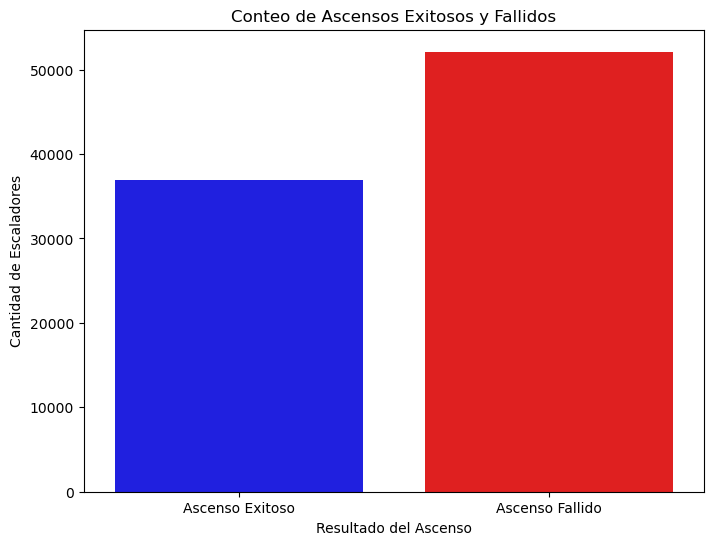

In [155]:
conteos = clean_df["msuccess"].value_counts()
porcentaje = clean_df["msuccess"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,6))

datos = clean_df["msuccess"].map({
    True: "Ascenso Exitoso",
    False : "Ascenso Fallido"
})
sns.countplot(x = datos , palette=["red", "blue"] , hue = datos ,  order = ["Ascenso Exitoso" , "Ascenso Fallido"] , legend = False)
plt.title("Conteo de Ascensos Exitosos y Fallidos")  
plt.xlabel("Resultado del Ascenso")
plt.ylabel("Cantidad de Escaladores")
plt.show()


In [156]:
exitos = conteos[True]
fallos = conteos[False]
total = exitos + fallos
porcentaje_exito = round((exitos / total) * 100 , 2)
porcentaje_fallo = round((fallos / total) * 100 , 2)

print(f"La cantidad de personas que tuvieron un ascenso exitoso es de {exitos}, esto representa un {porcentaje_exito}% del total de ascensos que se hicieron")
print("-" * 150)
print(f"La cantidad de personas que tuvieron un ascenso fallido es de {fallos}, esto representa un {porcentaje_fallo}% del total de ascensos que se hicieron")

La cantidad de personas que tuvieron un ascenso exitoso es de 36966, esto representa un 41.49% del total de ascensos que se hicieron
------------------------------------------------------------------------------------------------------------------------------------------------------
La cantidad de personas que tuvieron un ascenso fallido es de 52123, esto representa un 58.51% del total de ascensos que se hicieron


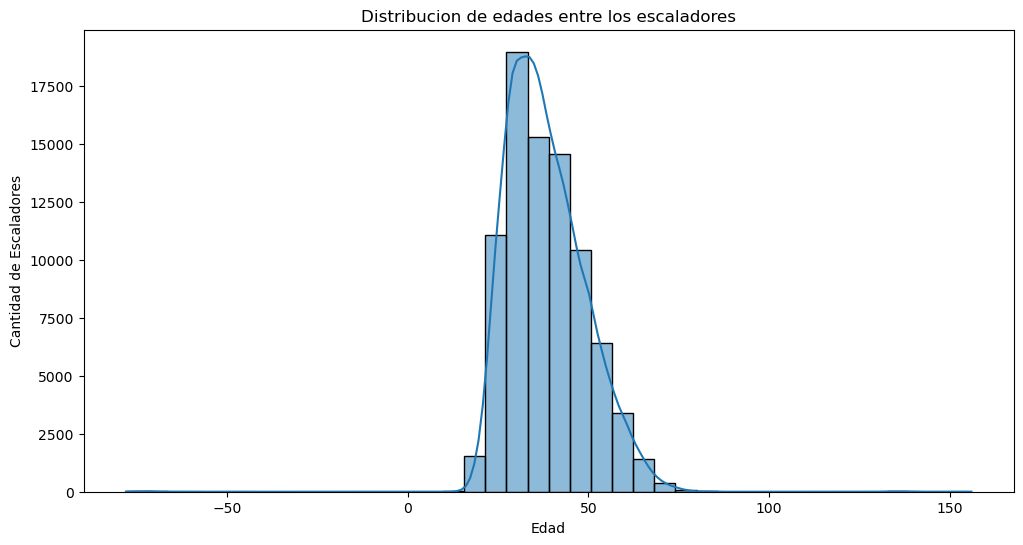

In [157]:
plt.figure(figsize=(12,6))
# se leyo la documentacion como ayuda = [https://seaborn.pydata.org/generated/seaborn.histplot.html]  
sns.histplot(clean_df, x = "age" , bins = 40 , kde=True)
plt.title("Distribucion de edades entre los escaladores")
plt.xlabel("Edad")
plt.ylabel("Cantidad de Escaladores")
plt.show()


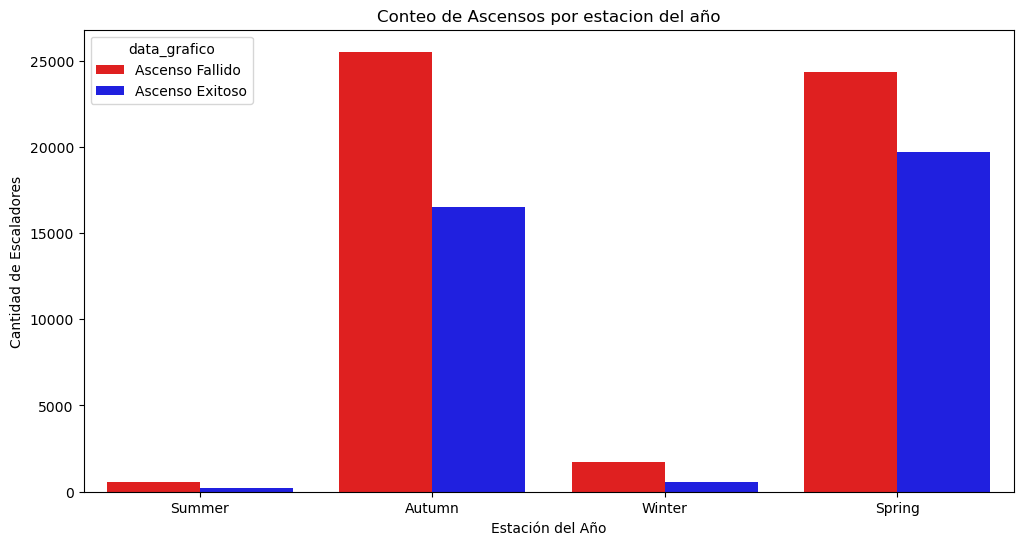

In [158]:
copia = clean_df.copy()

copia["data_grafico"] = copia["msuccess"].map({
    True: "Ascenso Exitoso",
    False : "Ascenso Fallido"
})

plt.figure(figsize=(12,6))
sns.countplot(data = copia , hue = "data_grafico" , x = "season" , palette = ["red" , "blue"] , order = ["Summer" , "Autumn" , "Winter" , "Spring"] ) 
plt.title("Conteo de Ascensos por estacion del año")
plt.xlabel("Estación del Año")
plt.ylabel("Cantidad de Escaladores")
plt.show()

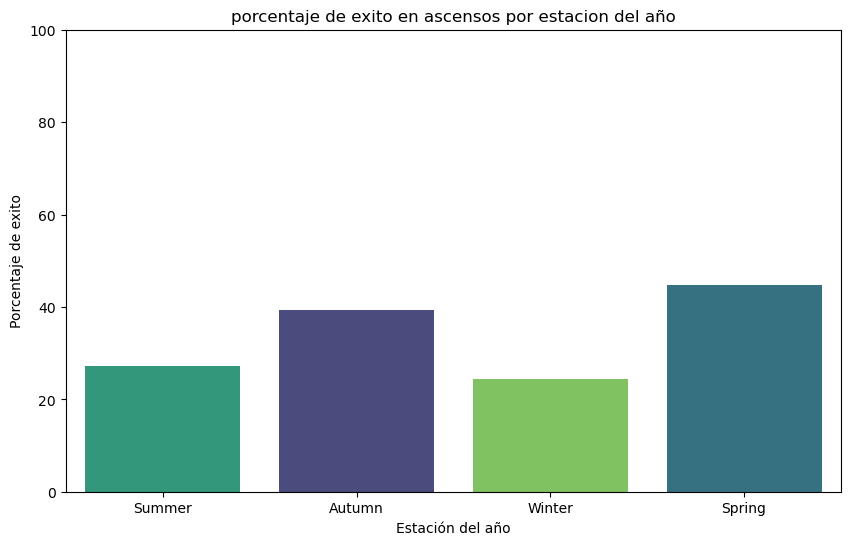

In [159]:
exito_estacion = clean_df.groupby("season")["msuccess"].mean().reset_index()
exito_estacion["porcentaje"] = exito_estacion["msuccess"] * 100

plt.figure(figsize=(10,6))

sns.barplot(data = exito_estacion , x = "season" , hue = "season", y = "porcentaje" , palette="viridis" , order = ["Summer" , "Autumn" , "Winter" , "Spring"] , legend=False)

plt.title("porcentaje de exito en ascensos por estacion del año")
plt.xlabel("Estación del año")
plt.ylabel("Porcentaje de exito")
plt.ylim(0, 100)
plt.show()


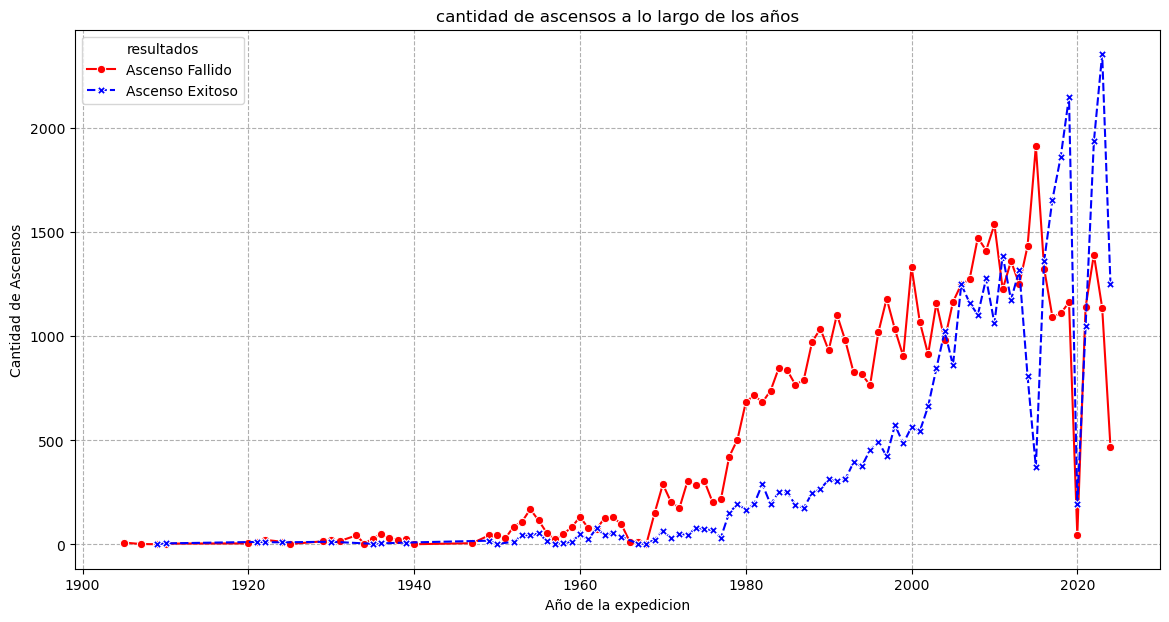

In [160]:
ascensos = clean_df.groupby(["year" , "msuccess"]).size().reset_index(name="conteo")

ascensos["resultados"] = ascensos["msuccess"].map({
    True: "Ascenso Exitoso",
    False : "Ascenso Fallido"
})

plt.figure(figsize=(14,7))
sns.lineplot(data = ascensos , x = "year" , y = "conteo" , hue = "resultados" , style = "resultados" ,markers=True , palette = ["red" , "blue"])
plt.title("cantidad de ascensos a lo largo de los años")
plt.xlabel("Año de la expedicion")
plt.ylabel("Cantidad de Ascensos")
plt.grid(True , linestyle="--" )
plt.show()  

La correlacion entre la altura y la montaña es de -0.3321


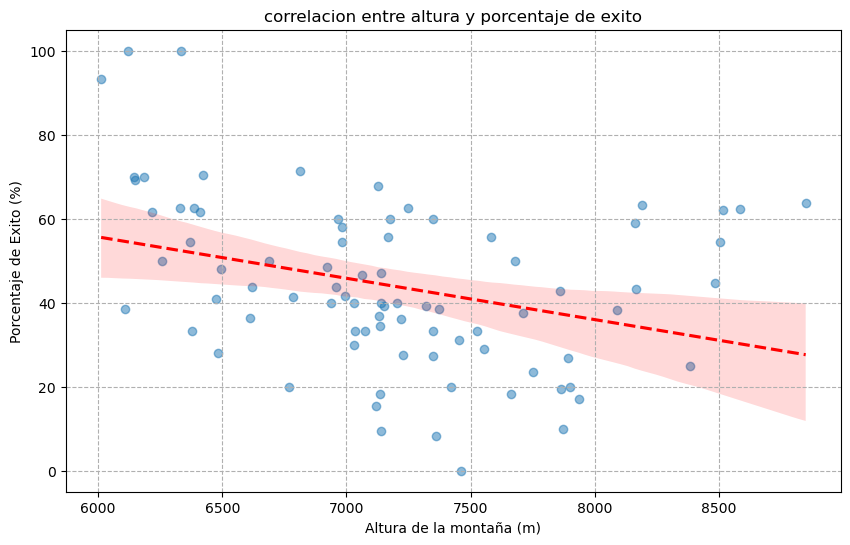

In [161]:
df_actual = clean_df[["peakid", "pkname", "heightm", "success_exp", "failed_exp", "peak_success_p"]].drop_duplicates(subset = "peakid").reset_index(drop=True)
df_actual["total_exp"] = df_actual["success_exp"] + df_actual["failed_exp"]

df_actual = df_actual[df_actual["total_exp"] >= 10].copy()

correlacion = df_actual["heightm"].corr(df_actual["peak_success_p"])
print(f"La correlacion entre la altura y la montaña es de {round(correlacion , 4)}")

plt.figure(figsize=(10,6))
sns.regplot(data = df_actual , x = "heightm" , y = "peak_success_p" , scatter_kws = {"alpha" : 0.5} , line_kws = {"color" : "red" , "linestyle" : "--"})

plt.title("correlacion entre altura y porcentaje de exito")
plt.xlabel("Altura de la montaña (m)")
plt.ylabel("Porcentaje de Exito (%)")
plt.grid(True , linestyle="--" )
plt.show()

In [162]:
data = clean_df.copy()

In [163]:
clean_df.dropna(inplace=True)

In [164]:
x = clean_df[["age", "sex", "citizen", "season", "heightm", "year", "success_exp", "failed_exp"]]

y = clean_df[["msuccess"]]

x_train , x_test , y_train , y_test = train_test_split( x , y , test_size=0.3 , random_state=30 , stratify=y)

print(f"tamaño x_train: {x_train.shape}")
print(f"tamaño x_test: {x_test.shape}")  
print(f"tamaño y_train: {y_train.shape}")
print(f"tamaño y_test: {y_test.shape}")  

tamaño x_train: (58565, 8)
tamaño x_test: (25100, 8)
tamaño y_train: (58565, 1)
tamaño y_test: (25100, 1)


In [165]:
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["age", "heightm", "year", "success_exp", "failed_exp"]),
        ("cat", OneHotEncoder(handle_unknown='ignore'), ["sex", "citizen", "season"])
    ],
    remainder = "passthrough"
)

preprocesamiento.fit(x_train)

x_train_procesado = preprocesamiento.transform(x_train)
x_test_procesado = preprocesamiento.transform(x_test)

print(f"tamaño x_train_procesado: {x_train_procesado.shape}")
print(f"tamaño x_test_procesado: {x_test_procesado.shape}")

tamaño x_train_procesado: (58565, 230)
tamaño x_test_procesado: (25100, 230)


## KNN

respecto a la pregunta da error por valores nan

In [166]:
clean_df.dropna(inplace=True)

In [167]:
pipe_line = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", KNeighborsClassifier(n_neighbors=35))
])

pipe_line.fit(x_train , y_train.values.ravel()) 
#https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html se leyo la documentacion
y_pred_knn = pipe_line.predict(x_test)

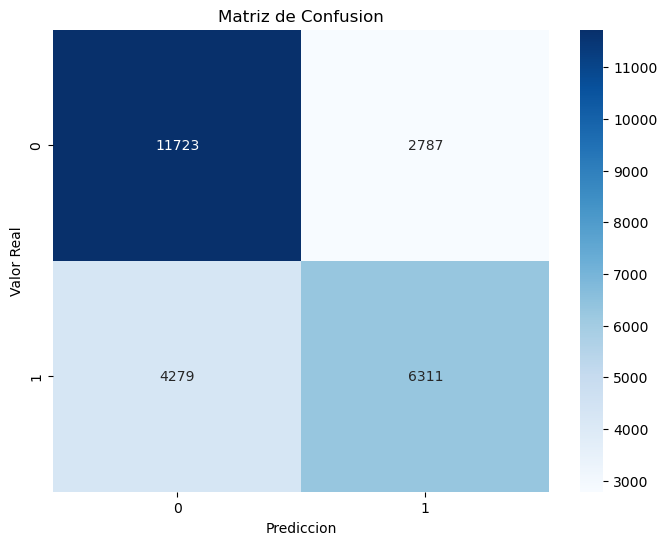

In [168]:
matriz_confusion = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8,6))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusion")
plt.xlabel("Prediccion")
plt.ylabel("Valor Real")
plt.show()

## arbol de decision

In [169]:
from sklearn.tree import DecisionTreeClassifier

pipe_line = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", DecisionTreeClassifier(max_depth=5))
])
#se usa 6 porqiue numeros mas grandes se ve. bastante mal
pipe_line.fit(x_train , y_train.values.ravel()) 
y_pred_tree = pipe_line.predict(x_test)

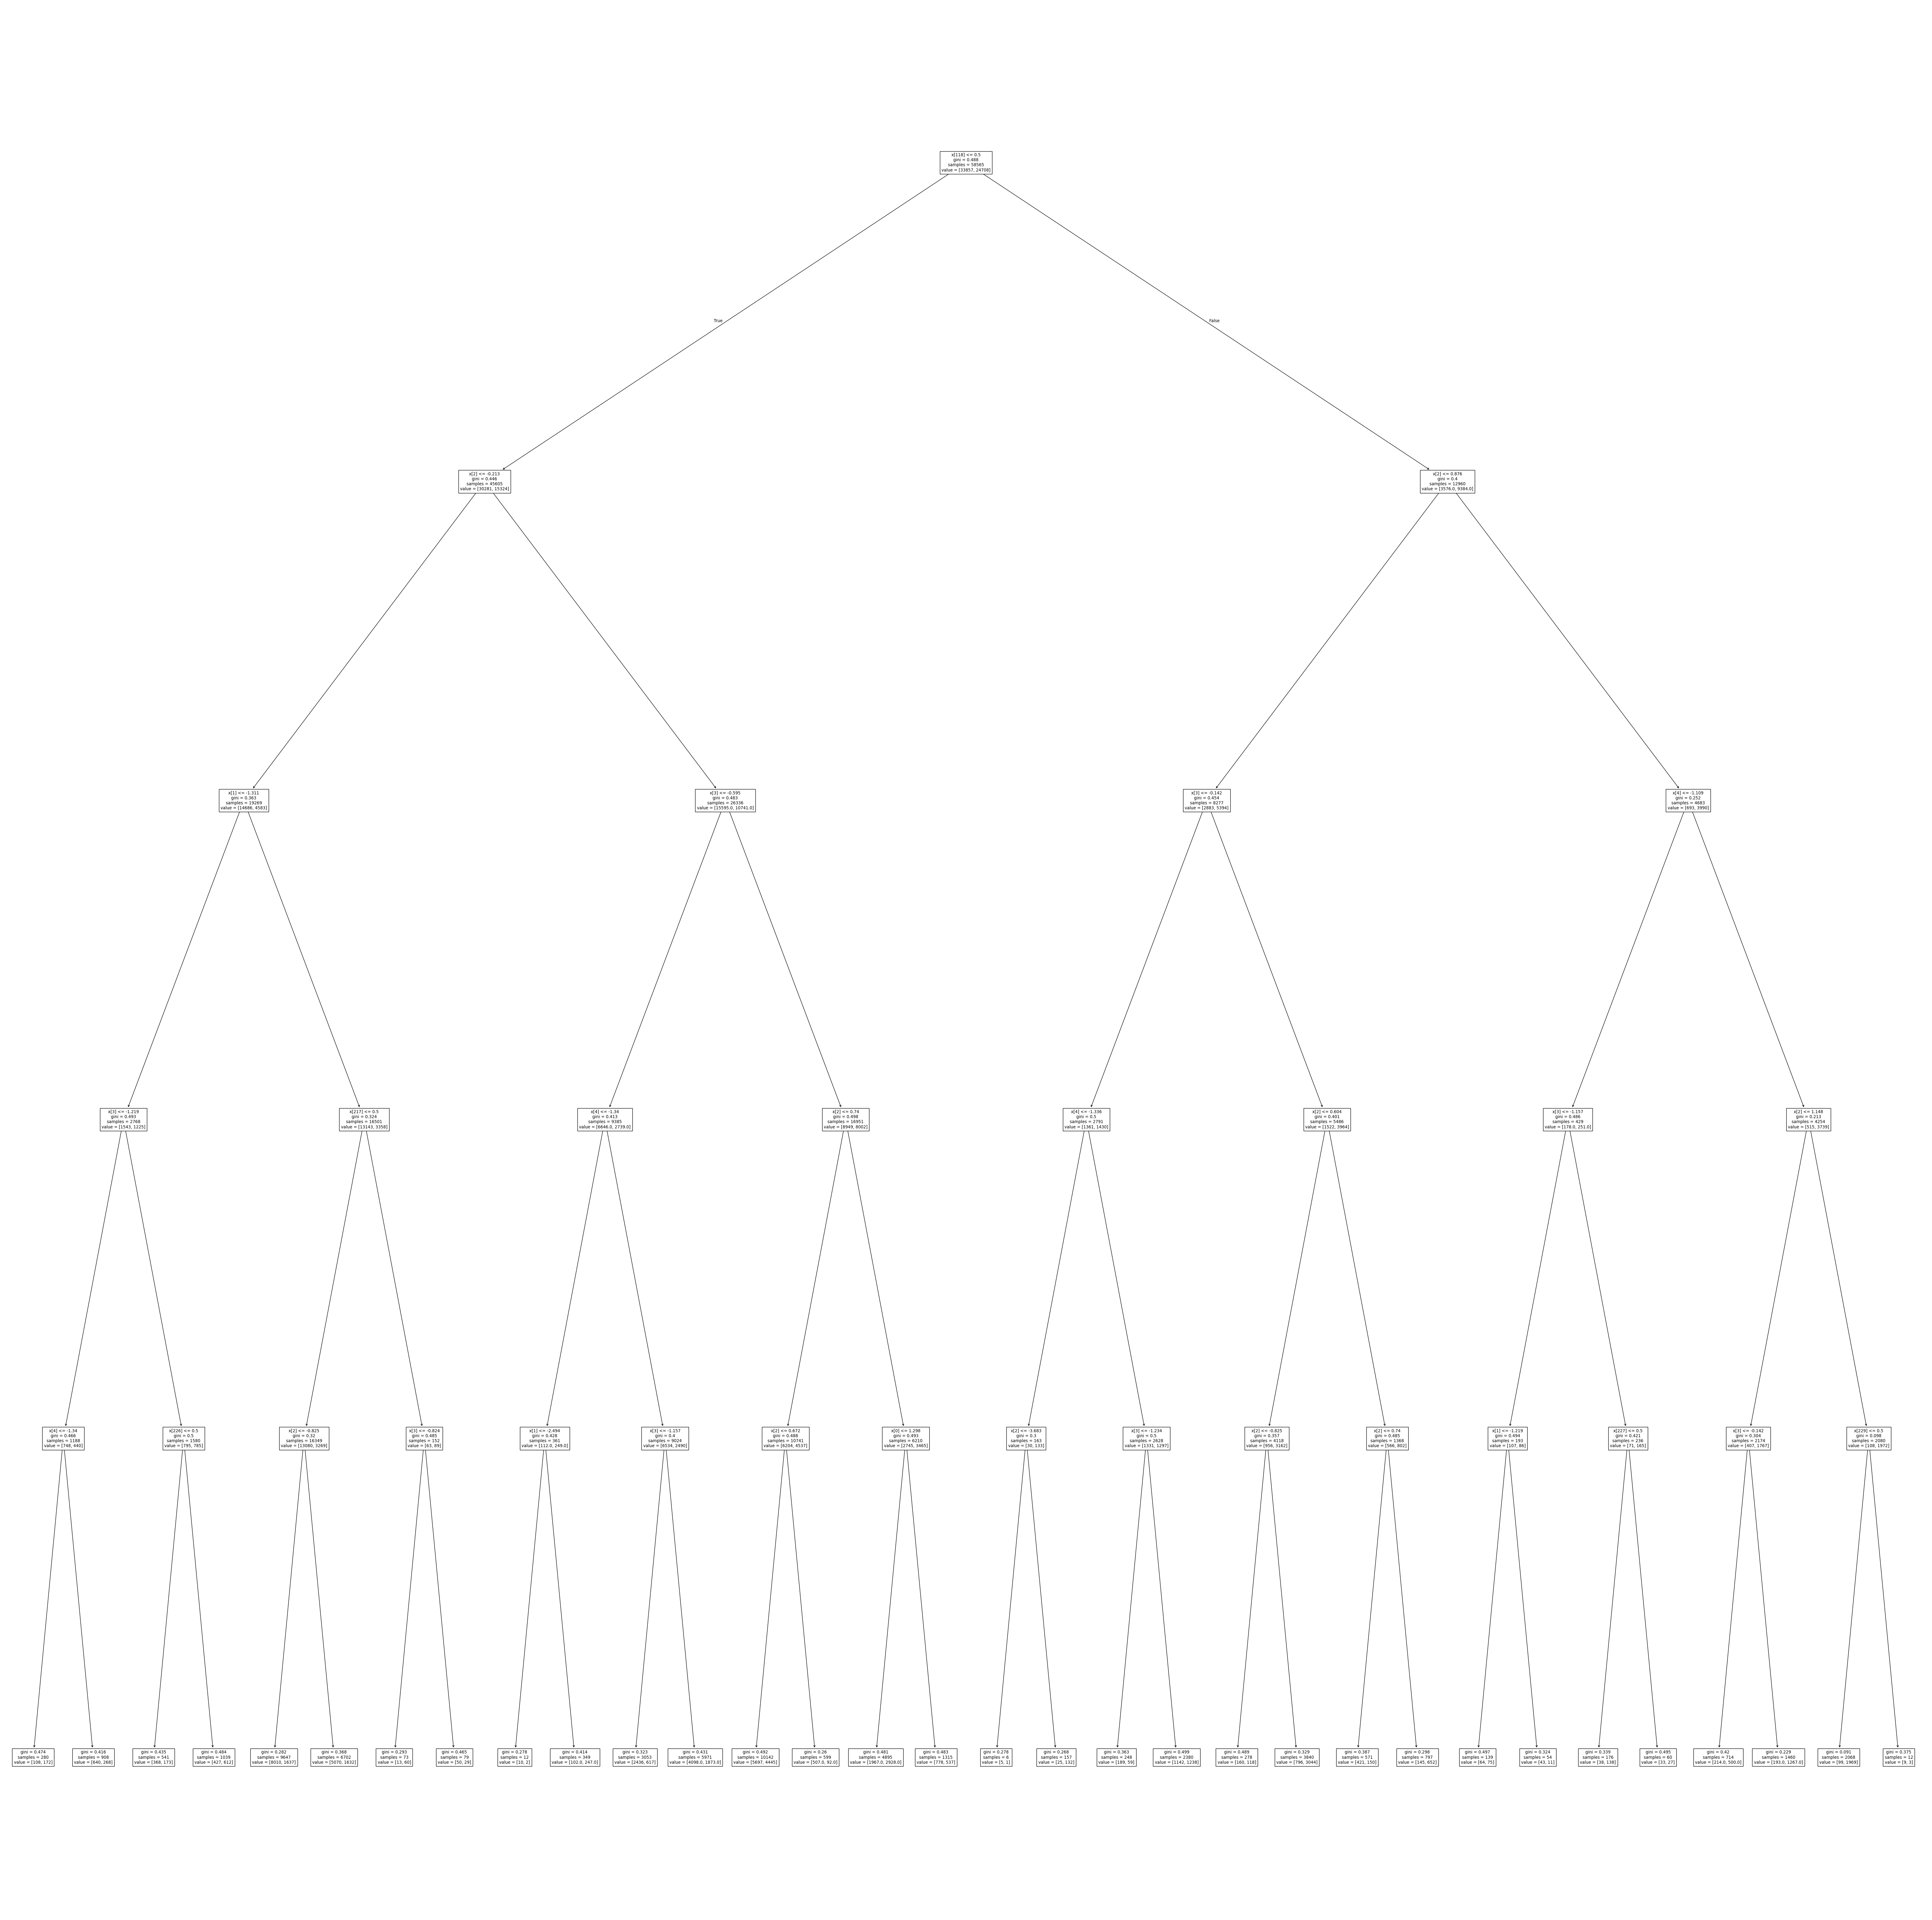

In [170]:
from sklearn.tree import plot_tree
fig = plt.figure(figsize=(80,80))
ax = fig.add_subplot(111)
plot_tree(pipe_line.named_steps["clasificador"], ax=ax)
#practicamente copiado a la clase 23
#solo se puso 80,80 para que se vea con mayor resolucion/mejor
plt.show()

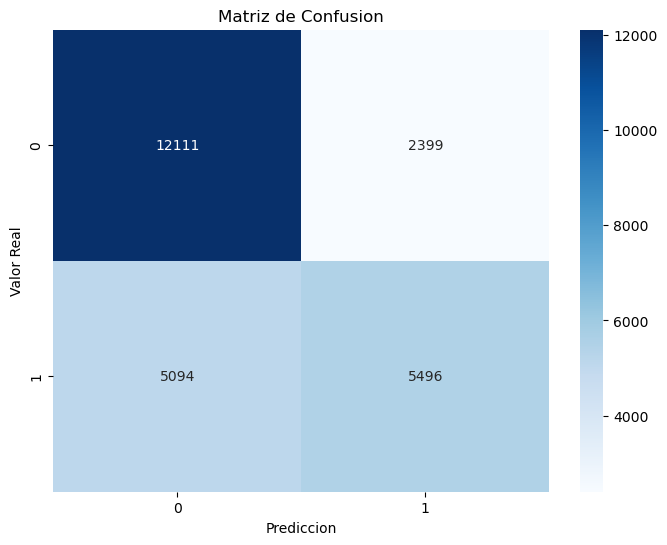

In [171]:
matriz_confusion = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(8,6))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusion")
plt.xlabel("Prediccion")
plt.ylabel("Valor Real")
plt.show()

REGRESION LOGISTICA

In [172]:
from sklearn.linear_model import LogisticRegression

regresion = LogisticRegression(random_state=100, max_iter=100000000)

pipe_line = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", regresion)
])


pipe_line.fit(x_train , y_train.values.ravel()) 
y_pred_logistic = pipe_line.predict(x_test)

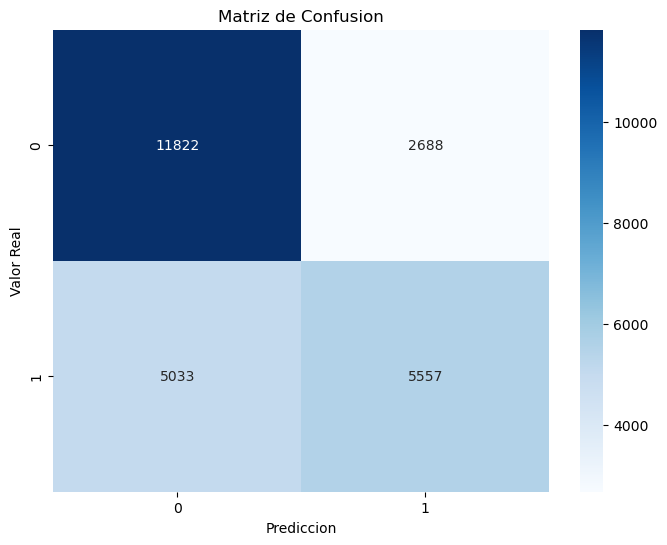

In [173]:
matriz_confusion = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(8,6))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusion")
plt.xlabel("Prediccion")
plt.ylabel("Valor Real")
plt.show()  

## CONCLUSIONES

si bien esto no es una buena en un entorno real, al observar la tarea vemos que los datos nulos/malos en el intervalo que se espera son datos mimnimos en relacion al total, es decir, los cambios son minimos ahora , puesto que no quede contento con el resultado, vere que sucede si en ves de  usar dropna, se remplaza los valores por 0 [juguemos un poco con una IA confundida(no es IA es solo un modelo)]

In [178]:
clean_df = data.copy()

clean_df = clean_df.fillna(0)

In [179]:
x = clean_df[["age", "sex", "citizen", "season", "heightm", "year", "success_exp", "failed_exp"]]

y = clean_df[["msuccess"]]

x_train , x_test , y_train , y_test = train_test_split( x , y , test_size=0.3 , random_state=30 , stratify=y)

print(f"tamaño x_train: {x_train.shape}")
print(f"tamaño x_test: {x_test.shape}")  
print(f"tamaño y_train: {y_train.shape}")
print(f"tamaño y_test: {y_test.shape}")  

tamaño x_train: (62362, 8)
tamaño x_test: (26727, 8)
tamaño y_train: (62362, 1)
tamaño y_test: (26727, 1)


In [180]:
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["age", "heightm", "year", "success_exp", "failed_exp"]),
        ("cat", OneHotEncoder(handle_unknown='ignore'), ["sex", "citizen", "season"])
    ],
    remainder = "passthrough"
)

preprocesamiento.fit(x_train)

x_train_procesado = preprocesamiento.transform(x_train)
x_test_procesado = preprocesamiento.transform(x_test)

print(f"tamaño x_train_procesado: {x_train_procesado.shape}")
print(f"tamaño x_test_procesado: {x_test_procesado.shape}")

TypeError: Encoders require their input argument must be uniformly strings or numbers. Got ['int', 'str']

In [ ]:
pipe_line = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", KNeighborsClassifier(n_neighbors=35))
])

pipe_line.fit(x_train , y_train.values.ravel()) 
#https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html se leyo la documentacion
y_pred_knn = pipe_line.predict(x_test)

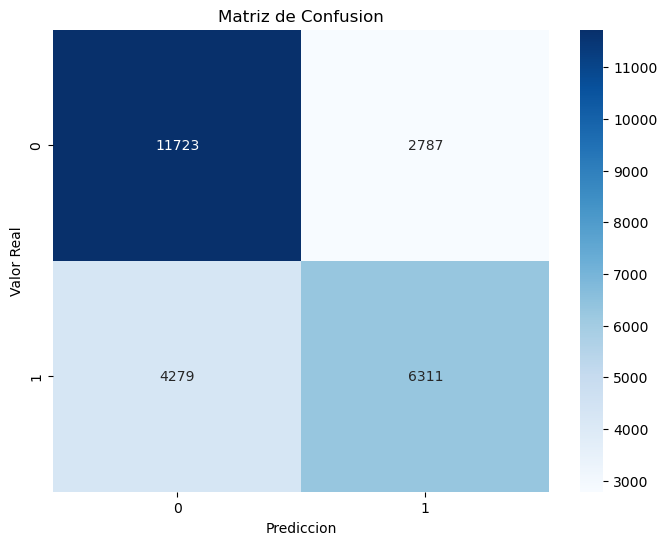

In [ ]:
matriz_confusion = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8,6))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusion")
plt.xlabel("Prediccion")
plt.ylabel("Valor Real")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

pipe_line = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", DecisionTreeClassifier(max_depth=5))
])
#se usa 6 porqiue numeros mas grandes se ve. bastante mal
pipe_line.fit(x_train , y_train.values.ravel()) 
y_pred_tree = pipe_line.predict(x_test)

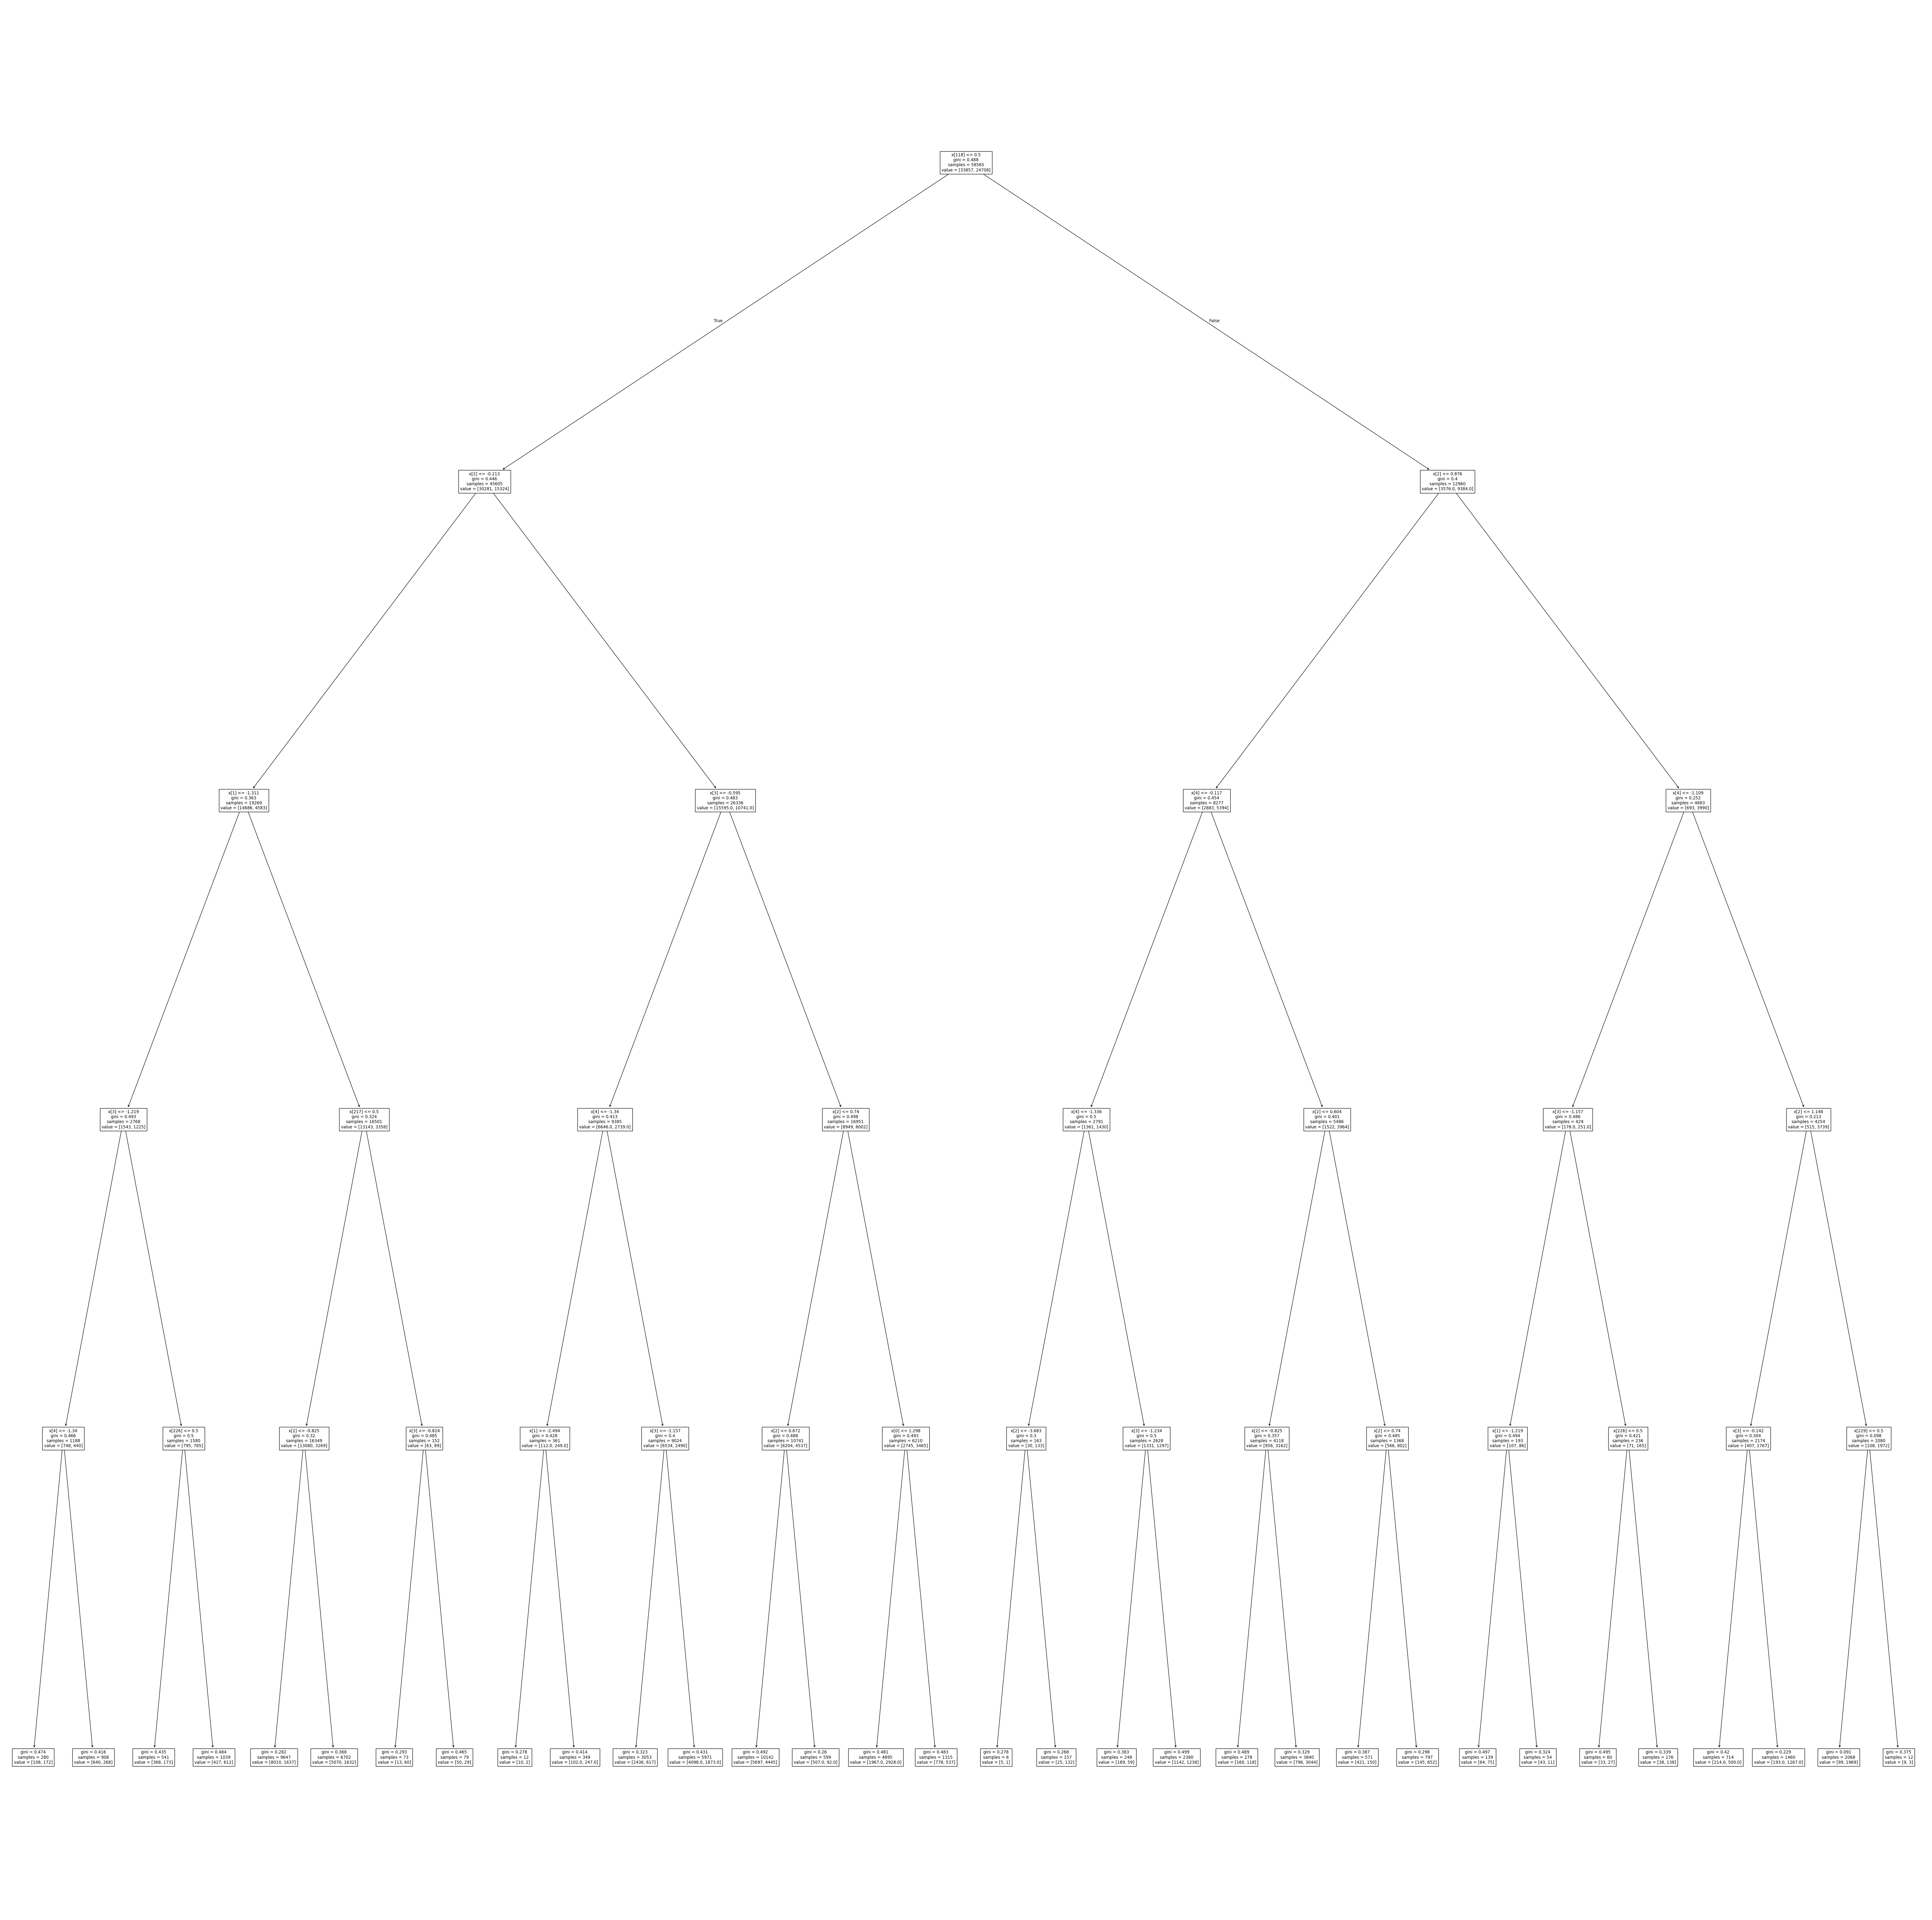

In [ ]:
from sklearn.tree import plot_tree
fig = plt.figure(figsize=(80,80))
ax = fig.add_subplot(111)
plot_tree(pipe_line.named_steps["clasificador"], ax=ax)
#practicamente copiado a la clase 23
#solo se puso 80,80 para que se vea con mayor resolucion/mejor
plt.show()

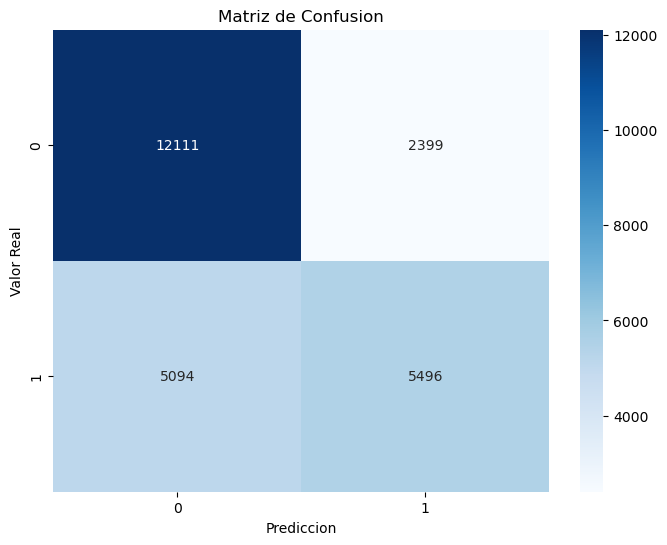

In [ ]:
matriz_confusion = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(8,6))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusion")
plt.xlabel("Prediccion")
plt.ylabel("Valor Real")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

regresion = LogisticRegression(random_state=100, max_iter=100000000)

pipe_line = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", regresion)
])


pipe_line.fit(x_train , y_train.values.ravel()) 
y_pred_logistic = pipe_line.predict(x_test)

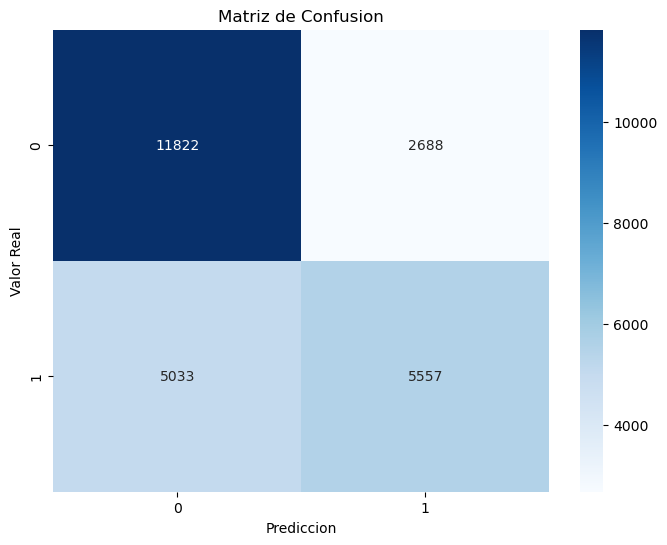

In [ ]:
matriz_confusion = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(8,6))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusion")
plt.xlabel("Prediccion")
plt.ylabel("Valor Real")
plt.show()  

podemos ver que sucedio algo que no esperaba, que es que  no se tomen los valores, aunque esto mismo tiene sentido, puesto que el modelo en su entrenamiento se dio cuenta que los valores con 0 no tenian importancia

veremos que sucede con random.randint(0 , 20000)

In [ ]:
from random import randint
clean_df = data.copy()

clean_df.fillna(randint(0 , 20000), inplace=True)

In [ ]:
x = clean_df[["age", "sex", "citizen", "season", "heightm", "year", "success_exp", "failed_exp"]]

y = clean_df[["msuccess"]]

x_train , x_test , y_train , y_test = train_test_split( x , y , test_size=0.3 , random_state=30 , stratify=y)

print(f"tamaño x_train: {x_train.shape}")
print(f"tamaño x_test: {x_test.shape}")  
print(f"tamaño y_train: {y_train.shape}")
print(f"tamaño y_test: {y_test.shape}")  

In [ ]:
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["age", "heightm", "year", "success_exp", "failed_exp"]),
        ("cat", OneHotEncoder(handle_unknown='ignore'), ["sex", "citizen", "season"])
    ],
    remainder = "passthrough"
)

preprocesamiento.fit(x_train)

x_train_procesado = preprocesamiento.transform(x_train)
x_test_procesado = preprocesamiento.transform(x_test)

print(f"tamaño x_train_procesado: {x_train_procesado.shape}")
print(f"tamaño x_test_procesado: {x_test_procesado.shape}")

In [ ]:
pipe_line = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", KNeighborsClassifier(n_neighbors=35))
])

pipe_line.fit(x_train , y_train.values.ravel()) 
#https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html se leyo la documentacion
y_pred_knn = pipe_line.predict(x_test)

In [ ]:
matriz_confusion = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8,6))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusion")
plt.xlabel("Prediccion")
plt.ylabel("Valor Real")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

pipe_line = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", DecisionTreeClassifier(max_depth=5))
])
#se usa 6 porqiue numeros mas grandes se ve. bastante mal
pipe_line.fit(x_train , y_train.values.ravel()) 
y_pred_tree = pipe_line.predict(x_test)

In [ ]:
from sklearn.tree import plot_tree
fig = plt.figure(figsize=(80,80))
ax = fig.add_subplot(111)
plot_tree(pipe_line.named_steps["clasificador"], ax=ax)
#practicamente copiado a la clase 23
#solo se puso 80,80 para que se vea con mayor resolucion/mejor
plt.show()

In [ ]:
matriz_confusion = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(8,6))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusion")
plt.xlabel("Prediccion")
plt.ylabel("Valor Real")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

regresion = LogisticRegression(random_state=100, max_iter=100000000)

pipe_line = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", regresion)
])


pipe_line.fit(x_train , y_train.values.ravel()) 
y_pred_logistic = pipe_line.predict(x_test)

In [ ]:
matriz_confusion = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(8,6))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusion")
plt.xlabel("Prediccion")
plt.ylabel("Valor Real")
plt.show()  